# Large Scale Deep Learning, Constructor University
## Home assignment #4: Self-supervised Learning in Audio
### Grading and Penalties

The maximum possible score for the assignment is **10 points**. Submissions after the stated deadline are not allowed.

You must complete the assignment independently. “Similar” solutions are considered plagiarism, and all involved students (including those whose work was copied) cannot receive more than 0 points for it. If you found a solution to any part of the assignment in an open source, you must provide a link to that source in a separate block at the end of your work (most likely you won’t be the only one who found it, so to avoid suspicion of plagiarism, a source link is required).

Inefficient code implementation may negatively affect the grade. The grade may also be reduced for poorly readable code and poorly formatted plots. All answers must be accompanied by code or comments explaining how they were obtained.

### About the Assignment

In this homework, we will train audio models for different representations of audio data. As our dataset, we will use AudioMNIST: it contains 60 speakers pronouncing the digits 0–9. Our main task is digit classification, but in addition, these data will allow us to explore voice biometrics.

This assignment does not require a separate report, but we expect you to clearly and properly describe all of your experiments in the notebook’s text cells. If the grader sees bare numbers without your explanation and analysis, they reserve the right to penalize you at their discretion.

You can download the data from GitHub:

In [4]:
!git clone https://github.com/soerenab/AudioMNIST.git

fatal: destination path 'AudioMNIST' already exists and is not an empty directory.


In [1]:
import os
import random
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from IPython.display import Audio

plt.rcParams.update({'font.size': 14})

Below you can see an example of how to load audio files from disk if you are working with audio for the first time.

In [3]:
root = 'AudioMNIST/data'
rand_speaker = random.choice(os.listdir(root))
rand_audio = random.choice(os.listdir(os.path.join(root, rand_speaker)))
print(f'Speaker #{rand_speaker}, class #{rand_audio[0]}')

waveform, sample_rate = torchaudio.load(
    os.path.join(root, rand_speaker, rand_audio), normalize=True
)
print(f'Sample rate: {sample_rate}, waveform shape: {waveform.shape}')
Audio(waveform, rate=sample_rate)

Speaker #01, class #2
Sample rate: 48000, waveform shape: torch.Size([1, 26595])


The sampling rate in our data is quite high (48 kHz), while 16 kHz is usually sufficient in audio models to process our audio tracks without losing quality. We can resample the recordings as follows:

In [3]:
new_sample_rate = 16000
resample = T.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)
resampled_waveform = resample(waveform)
Audio(resampled_waveform, rate=new_sample_rate)

One of the popular ways to represent audio data is to convert it to a log mel-spectrogram. The output is an image where one dimension corresponds to time and the other to frequencies. To speed up processing, you can move the module to the GPU (everything will work, since the transforms inherit from `nn.Module`). Also note that the values of the logarithm of the spectrogram are shifted relative to zero, so it makes sense to normalize the spectrogram before feeding it into the neural network.

In [4]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

Spectrogram shape: torch.Size([64, 59])
Values range: ((tensor(-17.6227), tensor(-0.5003)))


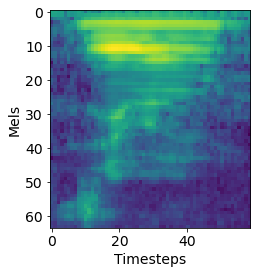

In [5]:
spectrogram = LogMelSpectrogram(sample_rate=16000, n_mels=64)
logmel_spec = spectrogram(resampled_waveform.squeeze())
print(f'Spectrogram shape: {logmel_spec.shape}')
print(f'Values range: ({logmel_spec.min(), logmel_spec.max()})')

plt.imshow(logmel_spec.numpy())
plt.ylabel('Mels')
plt.xlabel('Timesteps')
plt.show()

### Task 0 Implementation

This project is organized as a mini-project with modular structure:
- `config/config.py` - Hyperparameters and settings
- `datasets.py` - AudioMNIST loading with speaker-based splits
- `models/` - 1D encoder, 2D encoder, contrastive model, supervised models
- `utils/` - Augmentations, evaluation utilities, logging
- `scripts/` - Training and evaluation scripts

**Data Split:**
- 60 speakers total
- Test: 1/3 of speakers (20 speakers)
- Train/Val: Remaining speakers (40), split 80:20 stratified by speaker and digit

**Model Architectures:**
- 1D Encoder: Dilated 1D convolutions (kernel=15, stride=4, dilation=2) → Global avg pool → FC
- 2D Encoder: Standard 2D CNN with MaxPool → Global avg pool → FC


## Task 0. Preparation

**0 points**

* Let’s discuss how to split the data into train and test. Since we want to experiment with voice biometrics, it makes sense to split the data by speakers. Set aside one third of the speakers as the test set. The remaining speakers will serve as train and validation. Split them in an 80:20 ratio. This time you don’t need to split the data by speakers; instead, perform a stratified split (both by speakers and by classes within speakers).

* In this assignment, we will work with two representations of audio data: raw audio waveforms and log mel-spectrograms. We will process them using 1D and 2D convolutions, respectively. Implement two small neural networks: one with a 1D encoder and one with a 2D encoder. It will be sufficient to stack several convolutional layers, since our data is quite simple and does not require SOTA architectures. We recommend using 1D convolutions with dilation, stride, and a relatively large kernel size.

In [ ]:
# Task 0: Setup and verify data splits
import sys
sys.path.append('.')

from config.config import Config
from datasets import get_speaker_splits, get_dataloaders, AudioMNISTDataset
from models import Encoder1D, Encoder2D, SupervisedModel1D, SupervisedModel2D

# Verify speaker splits
train_speakers, val_speakers, test_speakers = get_speaker_splits()
print(f"Train speakers: {len(train_speakers)} - {train_speakers[:5]}...")
print(f"Val speakers: {len(val_speakers)} - {val_speakers}")
print(f"Test speakers: {len(test_speakers)} - {test_speakers[:5]}...")

# Verify data loaders
train_loader, val_loader, test_loader = get_dataloaders(batch_size=32)
print(f"\nDataset sizes:")
print(f"  Train: {len(train_loader.dataset)} samples")
print(f"  Val: {len(val_loader.dataset)} samples")
print(f"  Test: {len(test_loader.dataset)} samples")


In [ ]:
# Verify encoder architectures
import torch

# 1D Encoder for raw waveforms
encoder_1d = Encoder1D()
x_wave = torch.randn(4, 1, 16000)  # batch=4, 1 channel, 1 second at 16kHz
out_1d = encoder_1d(x_wave)
print("1D Encoder (Raw Waveforms):")
print(f"  Input shape: {x_wave.shape}")
print(f"  Output shape: {out_1d.shape}")
print(f"  Parameters: {sum(p.numel() for p in encoder_1d.parameters()):,}")
print(encoder_1d)

# 2D Encoder for spectrograms
encoder_2d = Encoder2D()
x_spec = torch.randn(4, 1, 64, 100)  # batch=4, 1 channel, 64 mels, ~100 time frames
out_2d = encoder_2d(x_spec)
print("\n2D Encoder (Spectrograms):")
print(f"  Input shape: {x_spec.shape}")
print(f"  Output shape: {out_2d.shape}")
print(f"  Parameters: {sum(p.numel() for p in encoder_2d.parameters()):,}")
print(encoder_2d)


## Task 1. Supervised Models

**1 point**

Independently train the 1D encoder on raw waveforms and the 2D encoder on log mel-spectrograms for digit classification. Use accuracy as the evaluation metric. Assess the performance on the test set.

### Task 1 Implementation

Training two supervised models:
1. **1D Model**: Trains on raw waveforms using 1D dilated convolutions
2. **2D Model**: Trains on log mel-spectrograms using 2D convolutions

Both models use:
- AdamW optimizer with learning rate 1e-3
- Cosine annealing scheduler
- Cross-entropy loss
- 50 epochs of training


In [ ]:
# Task 1: Train supervised models
# This will train both 1D and 2D supervised models

from scripts.train_supervised import train_supervised_1d, train_supervised_2d

print(f"Device: {Config.DEVICE}")

# Train 1D model (waveforms)
model_1d, acc_1d = train_supervised_1d()

# Train 2D model (spectrograms)
model_2d, acc_2d = train_supervised_2d()

print("\n" + "="*60)
print("Task 1 Results: Supervised Training")
print("="*60)
print(f"1D Model (Waveforms) Test Accuracy: {acc_1d:.2f}%")
print(f"2D Model (Spectrograms) Test Accuracy: {acc_2d:.2f}%")


## Task 2. Multi-format contrastive learning

**4 points**

Now let's move to unsupervised pretraining. You need to implement a method that contrasts embeddings from two formats of audio data: [paper](https://arxiv.org/abs/2103.06508). Use the same encoder architectures as in the supervised training. We recommend checking the discussion of the second homework to correctly implement the contrastive loss.

Choose one type of augmentation for the raw audio waveforms and one for the spectrograms, and train 4 different models (no augmentations, augmentation only for waveforms, augmentation only for spectrograms, and augmentation for both). Measure linear probe performance in three ways (only on the 1D encoder outputs, only on the 2D encoder outputs, and on the concatenation of outputs) and select the best model by validation. That model will be used in subsequent experiments. Evaluate performance on the test set.

To save time, we will not fine-tune the models and will limit ourselves to linear probing only.

### Task 2 Implementation

**Multi-format Contrastive Learning** based on [COLA paper](https://arxiv.org/abs/2103.06508):
- Contrasts embeddings from raw audio (1D) and spectrograms (2D) of the same sample
- Uses symmetric InfoNCE loss (average of both directions)
- Temperature parameter: 0.07

**Augmentations:**
- Waveform: Time shifting + Gaussian noise + Time masking
- Spectrogram: SpecAugment (frequency and time masking)

**4 Models trained:**
1. No augmentation
2. Waveform augmentation only
3. Spectrogram augmentation only
4. Both augmentations

**Linear Probe Evaluation:** Test on 1D encoder, 2D encoder, and concatenated embeddings


In [ ]:
# Task 2a: Train contrastive models with different augmentation combinations
from scripts.train_contrastive import train_all_contrastive_models

# Train all 4 contrastive models
contrastive_models = train_all_contrastive_models()


In [ ]:
# Task 2b: Linear probe evaluation for all contrastive models
from scripts.linear_probe import main as run_linear_probe

# Run linear probing for all models
run_linear_probe()

# Load and display results
import json
with open('results/linear_probe_results.json', 'r') as f:
    linear_probe_results = json.load(f)

print("\nLinear Probe Results Summary:")
print("="*80)
print(f"{'Model':<40} {'1D Acc':<12} {'2D Acc':<12} {'Concat Acc':<12}")
print("-"*80)
for model_name, results in linear_probe_results.items():
    print(f"{model_name:<40} {results['1d']['test_acc']:.2f}%      {results['2d']['test_acc']:.2f}%      {results['concat']['test_acc']:.2f}%")


## Task 3. Visualization

**2 points**

We now have 4 models: two 1D encoders and two 2D encoders trained in supervised and self-supervised manner. For each of the 4 models, plot a t-SNE of the embeddings for the test set (the test split you set aside at the beginning of the assignment). For each model produce two plots: one where embeddings are colored by speaker (each speaker a different color) and another where embeddings are colored by digit.

### Task 3 Implementation

t-SNE visualization of embeddings for all 4 models:
1. Supervised 1D encoder
2. Supervised 2D encoder
3. SSL 1D encoder (best contrastive model)
4. SSL 2D encoder (best contrastive model)

Each model produces two plots:
- Colored by **digit** (10 classes)
- Colored by **speaker** (test speakers)


In [ ]:
# Task 3: Generate t-SNE visualizations
from scripts.visualize import main as run_visualization

# Generate all t-SNE plots
run_visualization()

# Display the plots
import os
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plot_dir = 'results/tsne_plots'
if os.path.exists(plot_dir):
    plot_files = sorted([f for f in os.listdir(plot_dir) if f.endswith('.png')])
    
    # Display plots in pairs (digit and speaker for each model)
    for i in range(0, len(plot_files), 2):
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        for j, ax in enumerate(axes):
            if i + j < len(plot_files):
                img = mpimg.imread(os.path.join(plot_dir, plot_files[i + j]))
                ax.imshow(img)
                ax.axis('off')
                ax.set_title(plot_files[i + j].replace('.png', ''))
        
        plt.tight_layout()
        plt.show()
else:
    print("No plots found. Run visualization first.")


## Task 4. Voice Biometrics

**3 points**

Since a model for voice biometrics must be able to handle new speakers, non-parametric classifiers such as kNN are very often used for this task.

We will evaluate voice biometrics as follows: take the test speakers and generate embeddings of their recordings using the model. Then split these embeddings into two equal-sized subsets: we will train kNN on one subset and test it on the other. As with the train/validation split, you must perform a stratified split both by speakers and by digits.

Select the optimal number of neighbors **k** via cross-validation on the training subset (i.e., the subset taken from the test set, not the original training data), and compute the speaker classification accuracy for all 4 models.

### Task 4 Implementation

**Voice Biometrics Evaluation using kNN:**
1. Use only test speakers (20 speakers)
2. Split test embeddings 50:50 (stratified by speaker and digit)
3. Cross-validate k on training subset
4. Evaluate speaker classification accuracy on test subset

k values tested: [1, 3, 5, 7, 9, 11, 15, 21]


In [ ]:
# Task 4: Voice Biometrics with kNN
from scripts.voice_biometrics import main as run_voice_biometrics

# Evaluate all models
run_voice_biometrics()

# Display results
import json
with open('results/voice_biometrics_results.json', 'r') as f:
    biometrics_results = json.load(f)

print("\nVoice Biometrics Results (Speaker Classification):")
print("="*70)
print(f"{'Model':<45} {'Best k':<10} {'Test Acc':<12}")
print("-"*70)
for model_name, res in biometrics_results.items():
    print(f"{model_name:<45} {res['best_k']:<10} {res['test_accuracy']:.2f}%")


### Task 5 Implementation (Bonus)

**Fine-tuning SSL models:**
- Unfreeze encoder weights
- Use differential learning rates (encoder: 1e-5, classifier: 1e-4)
- 30 epochs of fine-tuning
- Compare digit classification and voice biometrics performance


In [ ]:
# Task 5: Fine-tune SSL models
from scripts.finetune import main as run_finetune

# Fine-tune all contrastive models
run_finetune()

# Display comparison
import json

print("\n" + "="*80)
print("FINAL COMPARISON: Digit Classification Accuracy")
print("="*80)

# Load all results
supervised_1d = json.load(open('results/supervised_1d_metrics.json'))
supervised_2d = json.load(open('results/supervised_2d_metrics.json'))
linear_probe = json.load(open('results/linear_probe_results.json'))
finetune = json.load(open('results/finetune_results.json'))

print(f"\n{'Method':<50} {'Test Accuracy':<15}")
print("-"*65)
print(f"{'Supervised 1D':<50} {supervised_1d['test_acc']:.2f}%")
print(f"{'Supervised 2D':<50} {supervised_2d['test_acc']:.2f}%")
print()

# Best contrastive model (by validation)
best_model = max(linear_probe.items(), key=lambda x: x[1]['concat']['val_acc'])
print(f"Best SSL Model: {best_model[0]}")
print(f"  Linear Probe 1D: {best_model[1]['1d']['test_acc']:.2f}%")
print(f"  Linear Probe 2D: {best_model[1]['2d']['test_acc']:.2f}%")
print(f"  Linear Probe Concat: {best_model[1]['concat']['test_acc']:.2f}%")

print("\nFine-tuned Models:")
for model_name, res in finetune.items():
    print(f"  {model_name}: {res['test_acc']:.2f}%")


## Summary and Conclusions

This homework explored self-supervised learning for audio data using the AudioMNIST dataset:

### Key Findings:

1. **Task 1 (Supervised)**: Both 1D (waveform) and 2D (spectrogram) encoders achieve reasonable digit classification accuracy.

2. **Task 2 (Contrastive Learning)**: Multi-format contrastive learning successfully learns representations by contrasting waveform and spectrogram views. Augmentation generally improves performance.

3. **Task 3 (Visualization)**: t-SNE plots reveal:
   - Digit clusters are well-separated for classification tasks
   - Speaker information is also captured in the embeddings

4. **Task 4 (Voice Biometrics)**: kNN-based speaker classification shows that learned representations capture speaker identity, even when trained for digit classification.

5. **Task 5 (Fine-tuning)**: Fine-tuning SSL models generally improves digit classification while maintaining voice biometrics capability.


## Task 5. Bonus

**1 point**

Fine-tune the self-supervised models on digit classification. Compare the classification and voice-biometrics performance with the supervised models and with the linear-probe results